# H3_3 — Árbol de Decisión para Regresión
## Predicción territorial del acceso a Internet en La Paz · Censo 2024

Ejercicio académico basado en la [referencia oficial del docente](https://github.com/ealaurel/MINERIA_DATOS_2026_2/blob/main/h3_3_Arboles_de_decisi%C3%B3n_regresion.ipynb).
El notebook reutiliza `src.decision_tree_regression`; todos los resultados se calculan al ejecutar.


## 1. Objetivo
Predecir el porcentaje de viviendas con acceso a Internet de cada municipio de La Paz a partir de características censales agregadas. Las conclusiones describen capacidad predictiva territorial, sin atribuir efectos causales.

## 2. Clasificación y regresión
H3_1/H3_2 clasifican una vivienda en 0/1. H3_3 utiliza `DecisionTreeRegressor` y predice una magnitud continua. Sus errores se expresan en puntos porcentuales.

## 3. Cambio de unidad de análisis
Una fila = un municipio. Cada municipio pesa una vez; la cantidad de viviendas no multiplica las observaciones del modelo.

## 4. Variable objetivo
`PORCENTAJE_ACCESO_INTERNET` = `pct_algun` del EDA = viviendas con `v19e_f=1` / universo TIC municipal × 100. Se conserva **sin especificar en el denominador**; no se utiliza `pct_algun_determinados`.


In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
from IPython.display import display, Markdown, Image

RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src/decision_tree_regression.py').is_file())
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))
from src.decision_tree_regression import (
    TARGET, MODEL_FEATURES, preparar_dataset_modelo, dividir_train_test,
    crear_pipeline, ejecutar_entrenamiento, resultado_serializable,
)
pd.set_option('display.max_colwidth', 120)


## 5. Construcción del dataset municipal
Se reutilizan `load_lapaz` y `read_dictionary` de `src.pipeline` y `summarize_groups` de `src.mining`. El universo conserva viviendas particulares de tipos 1–6 y ocupación 0/1. No se excluyen viviendas por su respuesta a Internet.

Los códigos geográficos se componen igual que en el EDA y se contrastan con el catálogo oficial. El módulo detiene el flujo si el target o los denominadores discrepan del EDA (tolerancia absoluta de 1e-8 pp).


In [2]:
preparado = preparar_dataset_modelo(RAIZ)
dataset = preparado.dataset
display(dataset)
display(pd.Series(preparado.audit['validacion_eda'], name='Validación con EDA').to_frame())
assert not dataset.municipio_codigo.duplicated().any()
assert dataset[TARGET].between(0, 100).all()
print('Municipios:', len(dataset), '| Viviendas del universo TIC:', preparado.audit['universo_tic'])


,municipio_codigo,municipio,pct_urbano,pct_con_energia,pct_computadora,pct_celular,promedio_habitaciones,promedio_personas,PORCENTAJE_ACCESO_INTERNET
0,20101,Nuestra Señora de La Paz,98.798873,98.799670,69.424520,97.311122,3.028833,2.909668,89.835453
1,20102,Palca,0.000000,86.921556,7.456743,86.024163,2.157416,2.854977,52.155570
2,20103,Mecapaca,0.000000,91.458607,28.235822,91.575640,2.692072,2.972113,67.163090
3,20104,Achocalla,88.813892,85.052464,26.635126,91.528675,2.346444,2.742897,68.859299
4,20105,El Alto,99.938570,97.166480,49.198478,95.914714,2.840895,2.945763,84.120068
...,...,...,...,...,...,...,...,...,...
82,21803,Chacarilla,0.000000,64.472191,4.895105,84.731935,1.509648,2.324631,48.354143
83,21901,Santiago de Machaca,0.000000,75.947226,6.524027,83.760084,1.788566,2.29161,45.669824
84,21902,Catacora,0.000000,77.581121,8.946078,75.674020,1.620059,3.147493,44.011799
85,22001,Caranavi,37.009630,83.112756,17.366947,88.631672,1.931692,2.750581,65.746407


,Validación con EDA
coincide,True
tolerancia_pp,0.0
max_diferencia_pp,0.0


Municipios: 87 | Viviendas del universo TIC: 1069838


## 6. Variables predictoras
Se agregan seis características sobre el universo TIC. Electricidad: códigos oficiales 1 (servicio público), 2 (generador), 3 (panel solar), 4 (otro) indican disponibilidad; 5 indica ausencia.

Computadora y celular siguen la limpieza de H3_1/H3_2: `9` y vacíos quedan ausentes. Las tasas de predictores se calculan entre respuestas determinadas de cada variable, sin convertir desconocidos en ausencia. Las medias excluyen valores inválidos según las reglas existentes (habitaciones 1–8, personas 0–9999).

**Habitaciones está truncada:** 8 representa ocho o más. La media de códigos es una aproximación, no un recuento exacto de habitaciones en esa categoría. Los conteos válidos municipales se conservan para auditar los denominadores.


In [3]:
display(preparado.X.describe().T)
display(pd.DataFrame(preparado.audit['conteos_validos_municipales']))
print(preparado.audit['denominadores'])


,count,mean,std,min,25%,50%,75%,max
pct_urbano,87.0,15.790897,23.852721,0.000000,0.000000,0.000000,27.885016,99.938570
pct_con_energia,87.0,78.045109,9.358596,43.857635,72.779774,78.608014,84.064505,98.799670
pct_computadora,87.0,11.782442,9.325380,2.051282,6.460308,9.153255,13.893348,69.424520
pct_celular,87.0,83.672491,4.971002,71.087928,80.223948,83.760084,86.550304,97.311122
promedio_habitaciones,87.0,2.112730,0.289454,1.509648,1.904488,2.100532,2.285276,3.028833
promedio_personas,87.0,2.698332,0.476598,2.006377,2.394105,2.600663,2.904970,4.970828


,municipio_codigo,validos_pct_urbano,validos_pct_con_energia,validos_pct_computadora,validos_pct_celular,validos_promedio_habitaciones,validos_promedio_personas,municipio,universo
0,20101,250931,250931,246907,246906,250931,250931,Nuestra Señora de La Paz,250931
1,20102,7585,7585,7282,7284,7585,7585,Palca,7585
2,20103,6849,6849,6683,6683,6849,6849,Mecapaca,6849
3,20104,16297,16297,15641,15641,16297,16297,Achocalla,16297
4,20105,297898,297898,292194,292195,297898,297898,El Alto,297898
...,...,...,...,...,...,...,...,...,...
82,21803,881,881,858,858,881,881,Chacarilla,881
83,21901,2956,2956,2851,2851,2956,2956,Santiago de Machaca,2956
84,21902,1695,1695,1632,1632,1695,1695,Catacora,1695
85,22001,21081,21081,20349,20346,21081,21081,Caranavi,21081


Target: todas las viviendas del universo TIC, incluido Internet sin especificar. Porcentajes predictores: respuestas determinadas de cada variable; 9/vacíos no se recodifican como No. Medias: valores válidos según H3_1/H3_2. No se imputa antes de agregar ni antes de separar train/test.


## 7. Prevención de data leakage
Una lista cerrada selecciona solo los seis predictores. Se excluyen todos los indicadores y agregados de Internet, el target y los identificadores municipales. No se imputa antes de agregar ni sobre todo el dataset; la mediana se aprende dentro de cada fold de train.


In [4]:
assert preparado.X.columns.tolist() == MODEL_FEATURES
assert TARGET not in preparado.X and 'municipio_codigo' not in preparado.X
print('Predictores:', MODEL_FEATURES)


Predictores: ['pct_urbano', 'pct_con_energia', 'pct_computadora', 'pct_celular', 'promedio_habitaciones', 'promedio_personas']


## 8. Estadística descriptiva del target
La distribución es municipal y cada territorio pesa una vez. Se verifica ausencia de targets NaN y de municipios duplicados antes del entrenamiento.


In [5]:
display(pd.Series(preparado.audit['estadisticos_target'], name='Porcentaje municipal').to_frame())
print('Targets ausentes:', dataset[TARGET].isna().sum())
print('Municipios duplicados:', dataset.municipio_codigo.duplicated().sum())


,Porcentaje municipal
minimo,24.327418
maximo,89.835453
promedio,49.386907
mediana,48.227535


Targets ausentes: 0
Municipios duplicados: 0


## 9. División train/test
`train_test_split`, test_size=0.20 y random_state=777, sin estratificación. Se mantiene la convención del proyecto frente a test_size=0.30 y random_state=22 del docente. Las listas de municipios se guardan en JSON y CSV para auditoría.


In [6]:
X_train, X_test, y_train, y_test = dividir_train_test(preparado.X, preparado.y)
print('Municipios totales:', len(dataset), '| Train:', len(X_train), '| Test:', len(X_test))
display(dataset.loc[X_test.index, ['municipio_codigo', 'municipio']])


Municipios totales: 87 | Train: 69 | Test: 18


,municipio_codigo,municipio
27,20601,Sorata
75,21601,Charazani
48,20905,Cairoma
19,20401,Puerto Acosta
26,20503,Aucapata
1,20102,Palca
63,21204,Puerto Pérez
76,21602,Curva
34,20608,Teoponte
30,20604,Quiabaya


## 10. Pipeline y modelo base
`SimpleImputer(strategy="median")` + `DecisionTreeRegressor(random_state=777)`, sin escalado. El árbol base ilustra el ajuste en train; test se mantiene reservado para el modelo elegido por CV.


In [7]:
display(crear_pipeline())
resultados = ejecutar_entrenamiento(RAIZ, prefer_cache=True, save_outputs=True)
resumen = resultado_serializable(resultados)
ejecucion = resultados['_runtime']
display(pd.Series(resumen['modelo_base']['metricas_train'], name='Árbol base — train').to_frame())


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputador', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",True
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will alway

,Árbol base — train
mse,0.0
rmse,0.0
mae,0.0
r2,1.0


## 11. Optimización con GridSearchCV
Producto cartesiano completo: max_depth=1..19, min_samples_split=2..9, min_samples_leaf=1..4. CV=5 con `neg_mean_squared_error` y n_jobs=-1. KFold sin shuffle, comportamiento de cv=5 para regresión. Búsqueda y reajuste exclusivamente sobre train; ninguna configuración se elige observando test.


In [8]:
grid = resumen['gridsearch']
display(pd.Series({k: grid[k] for k in ['combinaciones_evaluadas', 'ajustes_cv', 'reajustes_finales', 'best_score_', 'mejor_mse_cv', 'std_mse_cv']}).to_frame('CV'))
cv_resultados = pd.read_csv(RAIZ / resumen['artefactos']['gridsearch'])
display(cv_resultados.sort_values('rank_test_score').head(10))
display(pd.DataFrame({'fold': range(1, grid['cv'] + 1), 'mse_pp2': grid['mse_folds']}))


,CV
combinaciones_evaluadas,608.000000
ajustes_cv,3040.000000
reajustes_finales,1.000000
best_score_,-43.934604
mejor_mse_cv,43.934604
std_mse_cv,27.440629


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_modelo__max_depth,param_modelo__min_samples_leaf,param_modelo__min_samples_split,params,split0_test_score,split1_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
84,0.003754,0.000792,0.001702,0.000370,3,3,6,"{""modelo__max_depth"": 3, ""modelo__min_samples_leaf"": 3, ""modelo__min_samples_split"": 6}",-73.816421,-25.434329,...,-43.934604,27.440629,1,-13.256895,-19.700336,-12.969707,-19.949036,-19.889928,-17.153180,3.300821
85,0.003231,0.000783,0.001389,0.000346,3,3,7,"{""modelo__max_depth"": 3, ""modelo__min_samples_leaf"": 3, ""modelo__min_samples_split"": 7}",-73.816421,-25.434329,...,-43.934604,27.440629,1,-13.256895,-19.700336,-12.969707,-19.949036,-19.889928,-17.153180,3.300821
81,0.002738,0.000392,0.001450,0.000191,3,3,3,"{""modelo__max_depth"": 3, ""modelo__min_samples_leaf"": 3, ""modelo__min_samples_split"": 3}",-73.816421,-25.434329,...,-43.934604,27.440629,1,-13.256895,-19.700336,-12.969707,-19.949036,-19.889928,-17.153180,3.300821
80,0.003495,0.000460,0.001720,0.000251,3,3,2,"{""modelo__max_depth"": 3, ""modelo__min_samples_leaf"": 3, ""modelo__min_samples_split"": 2}",-73.816421,-25.434329,...,-43.934604,27.440629,1,-13.256895,-19.700336,-12.969707,-19.949036,-19.889928,-17.153180,3.300821
83,0.003863,0.000888,0.001717,0.000488,3,3,5,"{""modelo__max_depth"": 3, ""modelo__min_samples_leaf"": 3, ""modelo__min_samples_split"": 5}",-73.816421,-25.434329,...,-43.934604,27.440629,1,-13.256895,-19.700336,-12.969707,-19.949036,-19.889928,-17.153180,3.300821
82,0.002549,0.000205,0.001116,0.000089,3,3,4,"{""modelo__max_depth"": 3, ""modelo__min_samples_leaf"": 3, ""modelo__min_samples_split"": 4}",-73.816421,-25.434329,...,-43.934604,27.440629,1,-13.256895,-19.700336,-12.969707,-19.949036,-19.889928,-17.153180,3.300821
75,0.003087,0.000688,0.001292,0.000282,3,2,5,"{""modelo__max_depth"": 3, ""modelo__min_samples_leaf"": 2, ""modelo__min_samples_split"": 5}",-75.681223,-32.422193,...,-45.342720,26.893909,7,-10.665141,-16.511400,-11.500186,-17.778779,-17.197069,-14.730515,3.016940
74,0.003102,0.000496,0.001621,0.000352,3,2,4,"{""modelo__max_depth"": 3, ""modelo__min_samples_leaf"": 2, ""modelo__min_samples_split"": 4}",-75.681223,-32.422193,...,-45.342720,26.893909,7,-10.665141,-16.511400,-11.500186,-17.778779,-17.197069,-14.730515,3.016940
73,0.002476,0.000184,0.001051,0.000056,3,2,3,"{""modelo__max_depth"": 3, ""modelo__min_samples_leaf"": 2, ""modelo__min_samples_split"": 3}",-75.681223,-32.422193,...,-45.342720,26.893909,7,-10.665141,-16.511400,-11.500186,-17.778779,-17.197069,-14.730515,3.016940
72,0.003112,0.000643,0.001317,0.000250,3,2,2,"{""modelo__max_depth"": 3, ""modelo__min_samples_leaf"": 2, ""modelo__min_samples_split"": 2}",-75.681223,-32.422193,...,-45.342720,26.893909,7,-10.665141,-16.511400,-11.500186,-17.778779,-17.197069,-14.730515,3.016940


,fold,mse_pp2
0,1,73.816421
1,2,25.434329
2,3,80.785097
3,4,17.740843
4,5,21.896329


## 12. Mejores hiperparámetros
El modelo final es `best_estimator_`, reajustado sobre train. Se conserva la media y la desviación del MSE CV de la configuración seleccionada. La dispersión entre folds ayuda a describir estabilidad, pero no es un intervalo de confianza.


In [9]:
display(pd.Series(grid['mejores_parametros'], name='Valor seleccionado').to_frame())
assert grid['mejor_mse_cv'] == -grid['best_score_']
assert np.isclose(np.mean(grid['mse_folds']), grid['mejor_mse_cv'])


,Valor seleccionado
max_depth,3
min_samples_leaf,3
min_samples_split,2


## 13. Evaluación train/test
Se reportan los valores reales del modelo seleccionado, incluidos valores R² negativos cuando ocurran.

## 14. Interpretación de MAE, MSE, RMSE y R²
MAE y RMSE se expresan en **puntos porcentuales**; MSE en puntos porcentuales al cuadrado. R² compara el error con la variabilidad del target del conjunto evaluado. Un R² negativo indica un desempeño inferior a la predicción constante de la media de ese conjunto; no debe recortarse a cero.


In [10]:
metricas = pd.DataFrame(resumen['metricas']).T
display(metricas.style.format('{:.4f}'))
mtest = resumen['metricas']['test']
display(Markdown(f"Las predicciones presentan una diferencia absoluta promedio de **{mtest['mae']:.3f} puntos porcentuales** respecto al acceso municipal real. RMSE = **{mtest['rmse']:.3f} pp** y R² = **{mtest['r2']:.4f}**."))


,mse,rmse,mae,r2
train,18.8986,4.3472,3.4745,0.8754
test,28.0120,5.2926,4.5636,0.6574


Las predicciones presentan una diferencia absoluta promedio de **4.564 puntos porcentuales** respecto al acceso municipal real. RMSE = **5.293 pp** y R² = **0.6574**.

## 15. Baseline
`DummyRegressor(strategy="mean")` aprende la media de **train** y se evalúa en el mismo test. La comparación corresponde exclusivamente al problema municipal de regresión.


In [11]:
display(pd.DataFrame(resumen['comparacion_baseline']).set_index('modelo').style.format('{:.4f}'))
display(pd.Series(resumen['diferencia_arbol_menos_baseline'], name='Árbol menos baseline').to_frame())
print('Promedio aprendido en train:', resumen['baseline']['media_train'])


,mse,rmse,mae,r2
modelo,,,,
DummyRegressor,113.1971,10.6394,8.8989,-0.3846
DecisionTreeRegressor,28.0120,5.2926,4.5636,0.6574


,Árbol menos baseline
mse,-85.185080
rmse,-5.346776
mae,-4.335306
r2,1.041961


Promedio aprendido en train: 50.54705088762701


## 16. Importancia de variables
Se extrae `feature_importances_` del árbol final, ordenada de mayor a menor. Una importancia elevada indica mayor contribución a sus divisiones, sin identificar efectos causales. Cero indica que ese predictor no se utilizó en las divisiones de este árbol.


In [12]:
importancias = pd.DataFrame(resumen['importancia_variables'])
display(importancias.style.format({'importancia': '{:.6f}'}))
assert np.isclose(importancias.importancia.sum(), 1)
import matplotlib.pyplot as plt
importancias.sort_values('importancia').plot.barh(x='variable', y='importancia', color='#167f87', legend=False)
plt.xlabel('Importancia'); plt.ylabel('Predictor'); plt.tight_layout(); plt.show()


,variable,importancia
0,pct_celular,0.869245
1,pct_con_energia,0.130755
2,pct_urbano,0.000000
3,pct_computadora,0.000000
4,promedio_habitaciones,0.000000
5,promedio_personas,0.000000


/tmp/ipykernel_2486/1965678946.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.xlabel('Importancia'); plt.ylabel('Predictor'); plt.tight_layout(); plt.show()


## 17. Estructura y visualización del árbol
La figura limita la visualización a niveles 0–3; se conserva el modelo completo, sin entrenar otro árbol para dibujarlo.


,Estructura real
profundidad,3
nodos,13
hojas,7
visualizacion_max_depth,3


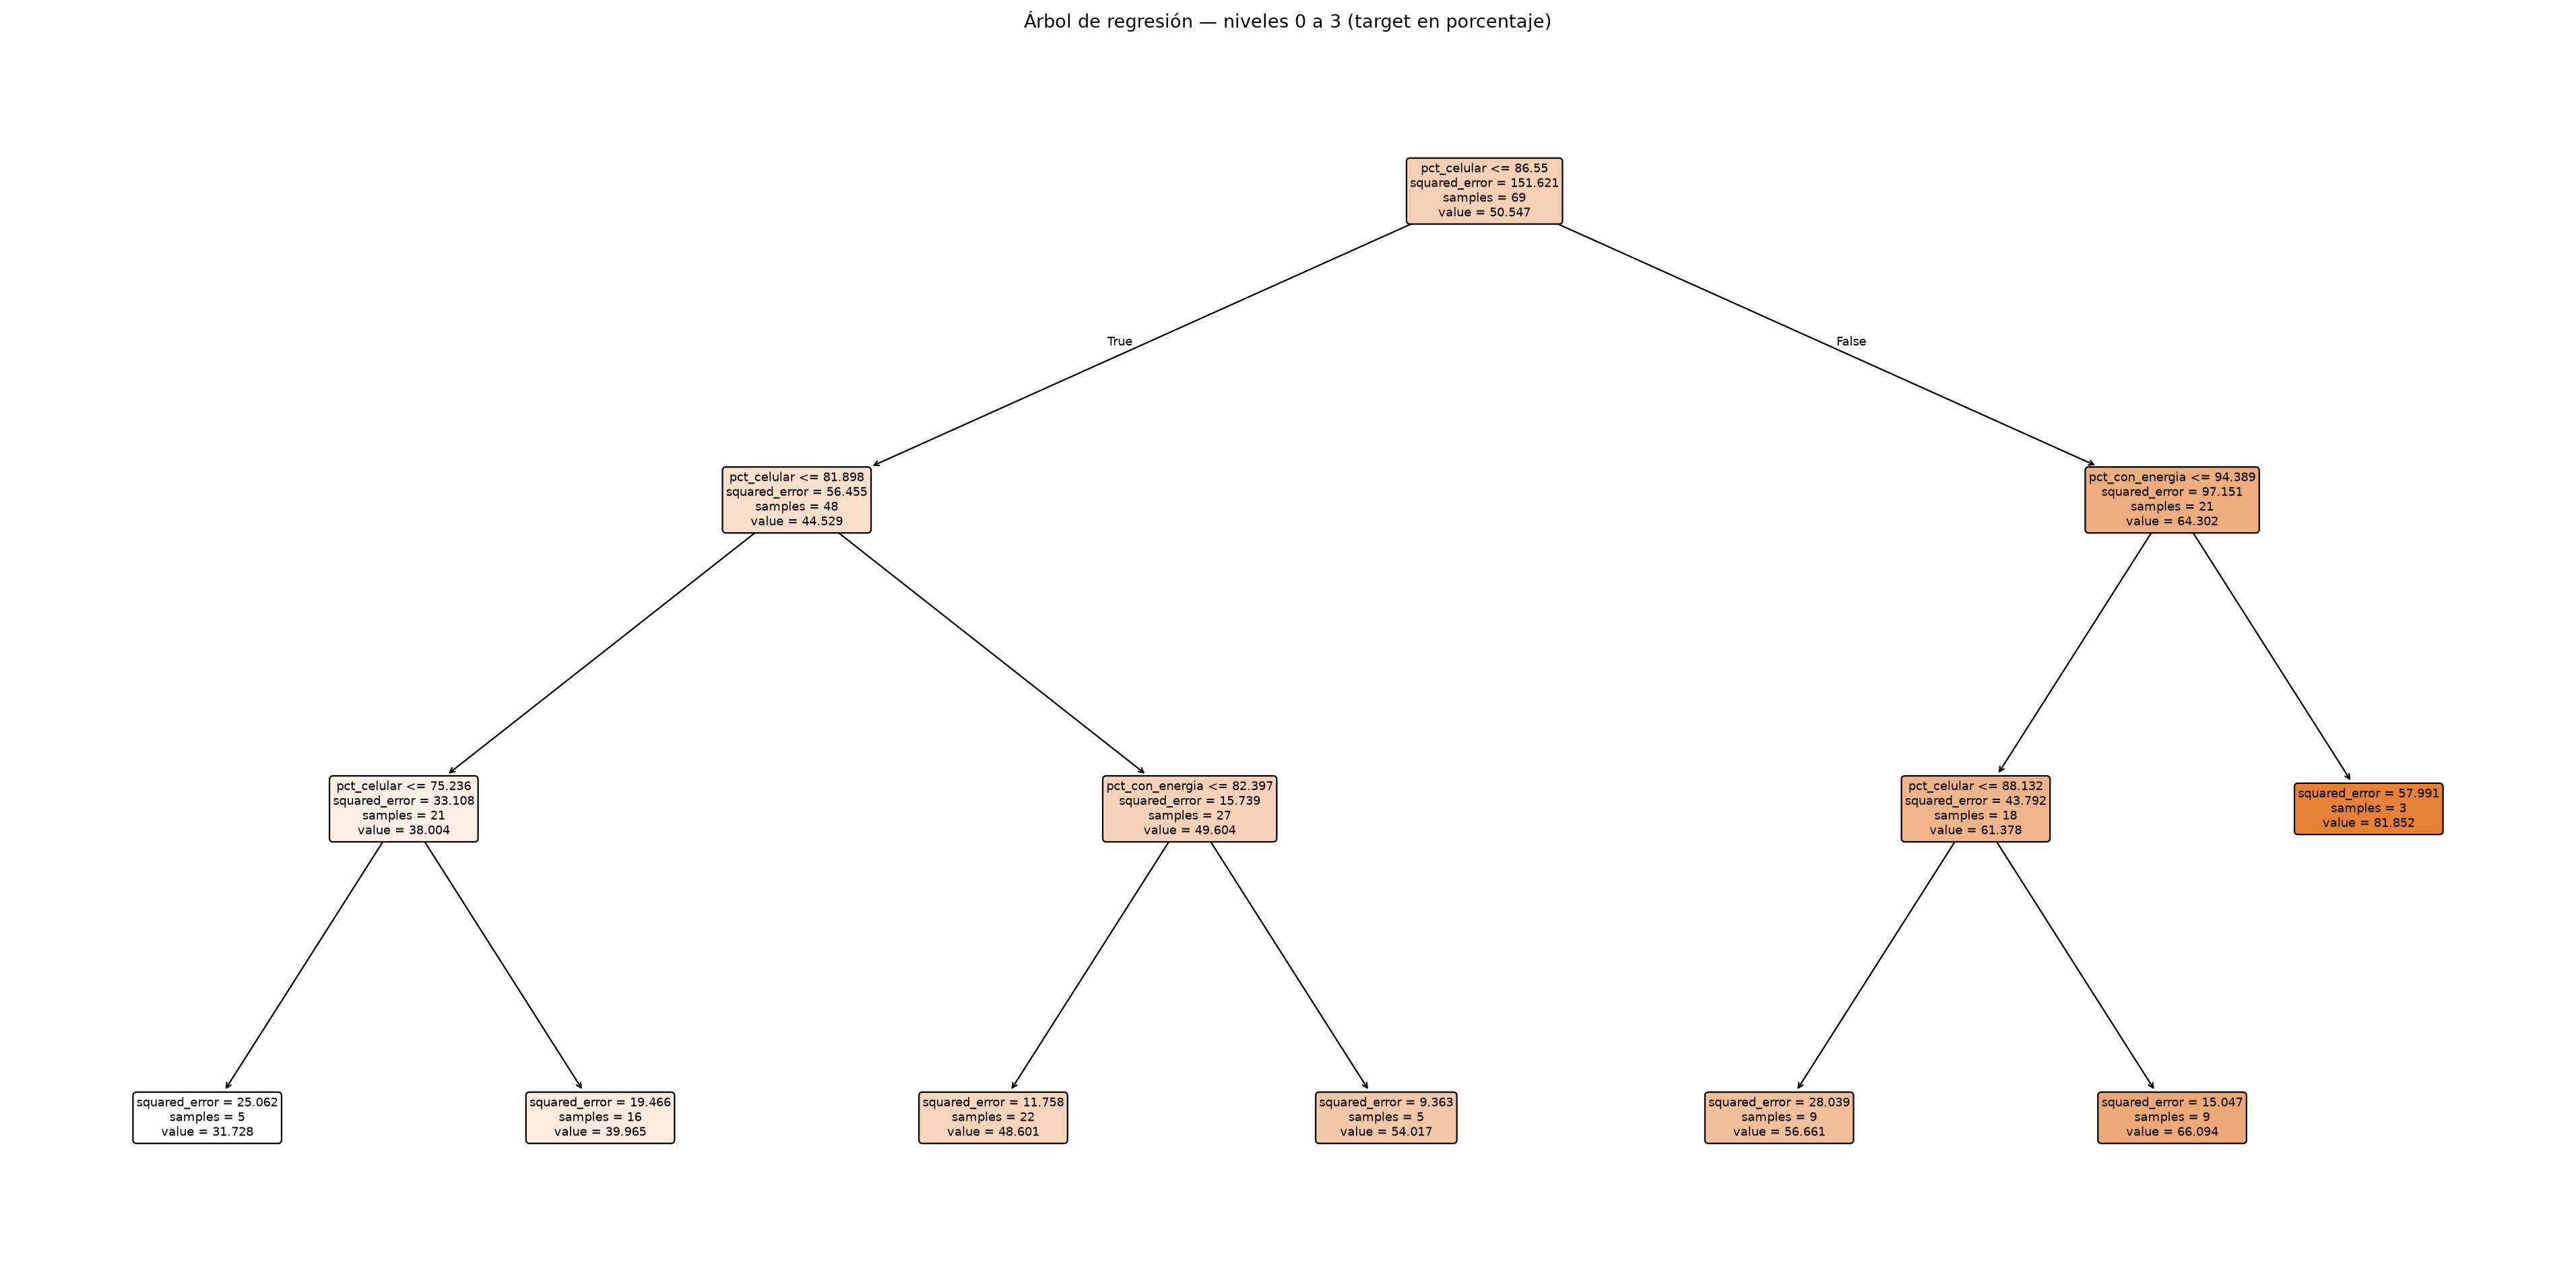

In [13]:
display(pd.Series(resumen['estructura_arbol'], name='Estructura real').to_frame())
display(Image(filename=str(RAIZ / resumen['artefactos']['grafico_arbol'])))


## 18. Real vs. predicho
X = porcentaje real; Y = porcentaje predicho; la referencia y=x representa predicción ideal. Todos los puntos pertenecen a test.


,municipio_codigo,municipio,valor_real,valor_predicho,error,error_absoluto
0,21006,Villa Libertad Licoma,51.042223,39.965180,11.077044,11.077044
1,20608,Teoponte,58.691873,48.601346,10.090527,10.090527
2,20805,La (Marka) San Andrés de Machaca,42.035967,48.601346,-6.565379,6.565379
3,21602,Curva,33.997585,39.965180,-5.967595,5.967595
4,20905,Cairoma,48.180703,54.016831,-5.836128,5.836128
5,20201,Achacachi,48.187377,54.016831,-5.829454,5.829454
6,21204,Puerto Pérez,35.006274,39.965180,-4.958906,4.958906
7,20604,Quiabaya,35.370237,39.965180,-4.594943,4.594943
8,21501,Ixiamas,44.373866,39.965180,4.408686,4.408686
9,21601,Charazani,35.603345,39.965180,-4.361834,4.361834


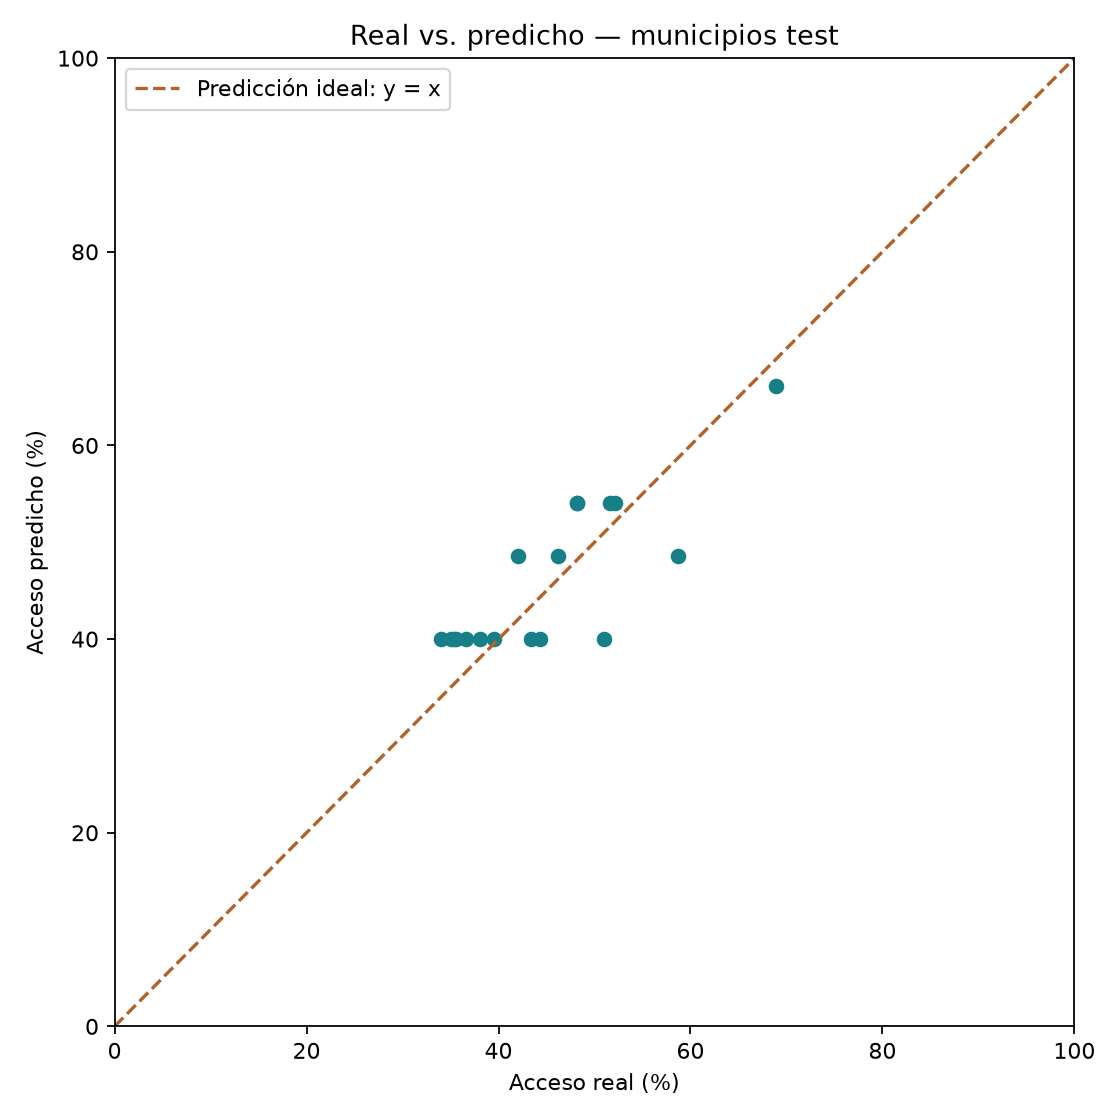

In [14]:
predicciones = pd.DataFrame(resumen['real_vs_predicho'])
display(predicciones)
display(Image(filename=str(RAIZ / resumen['artefactos']['grafico_predicciones'])))


## 19. Análisis de residuos
Residuo = real − predicho. Positivo indica subestimación del porcentaje; negativo indica sobreestimación. Su descripción no identifica causalidad.


,Test
definicion,real - predicho
promedio,-1.039068
minimo,-6.565379
maximo,11.077044
mae,4.56359


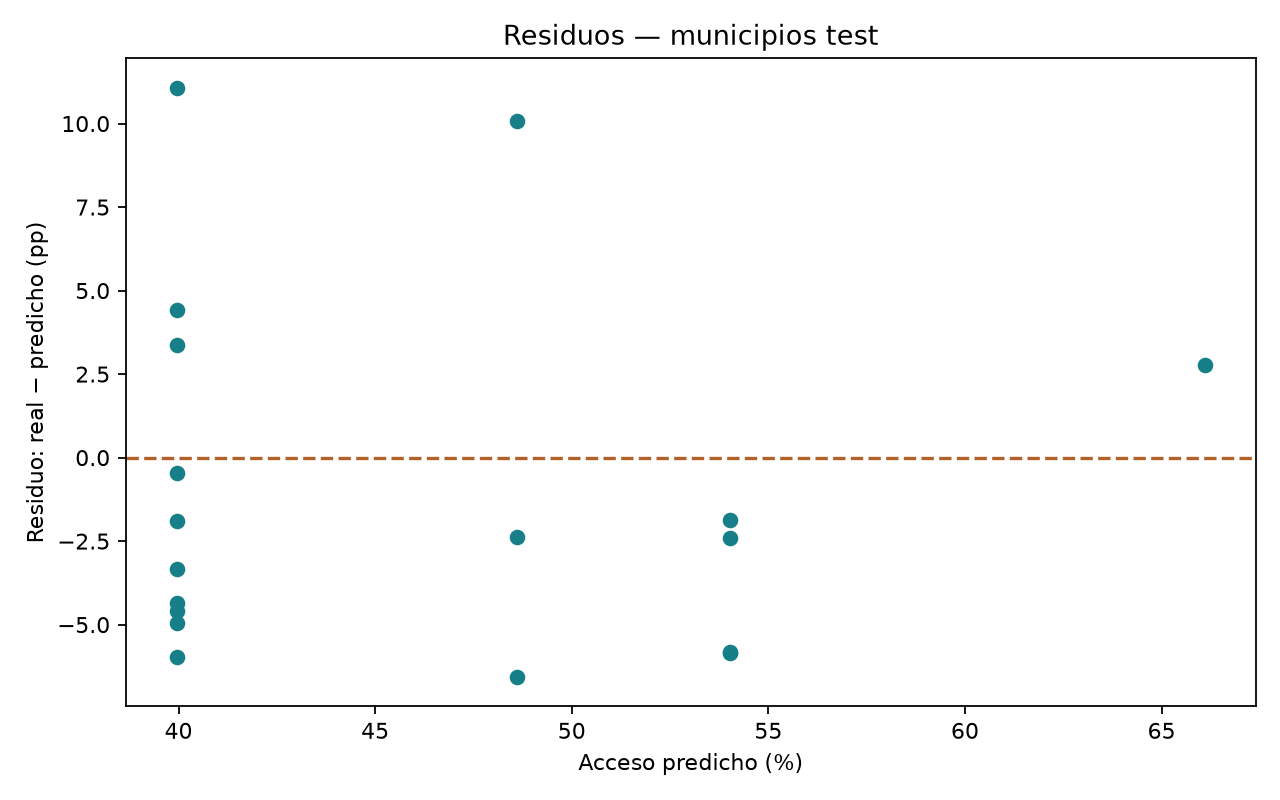

In [15]:
display(pd.Series(resumen['residuos'], name='Test').to_frame())
display(Image(filename=str(RAIZ / resumen['artefactos']['grafico_residuos'])))


## 20. Municipios con mayor error absoluto
Los errores permiten localizar los territorios peor representados por el modelo, sin eliminar esos municipios ni reajustar hiperparámetros observando test.


In [16]:
display(pd.DataFrame(resumen['municipios_mayor_error']).style.format({c: '{:.3f}' for c in ['valor_real', 'valor_predicho', 'error', 'error_absoluto']}))


,municipio_codigo,municipio,valor_real,valor_predicho,error,error_absoluto
0,21006,Villa Libertad Licoma,51.042,39.965,11.077,11.077
1,20608,Teoponte,58.692,48.601,10.091,10.091
2,20805,La (Marka) San Andrés de Machaca,42.036,48.601,-6.565,6.565
3,21602,Curva,33.998,39.965,-5.968,5.968
4,20905,Cairoma,48.181,54.017,-5.836,5.836


## 21. Interpretación académica

In [17]:
display(Markdown(resumen['interpretacion']))


Se predijo el porcentaje municipal de viviendas con Internet mediante pct_urbano, pct_con_energia, pct_computadora, pct_celular, promedio_habitaciones, promedio_personas. CV seleccionó {'max_depth': 3, 'min_samples_leaf': 3, 'min_samples_split': 2}. En test, la diferencia absoluta promedio fue 4.564 puntos porcentuales y RMSE=5.293 pp. R²=0.6574; la variabilidad explicada debe interpretarse con el pequeño test municipal. El árbol superó al baseline según MSE (árbol=28.012; baseline=113.197 pp²). La mayor importancia corresponde a pct_celular (0.8692). Los mayores errores se observan en Villa Libertad Licoma, Teoponte, La (Marka) San Andrés de Machaca, Curva, Cairoma. Las importancias describen contribuciones a la predicción; no permiten atribuir efectos causales.

## 22. Limitaciones

In [18]:
display(Markdown((chr(10) * 2).join(f'- {item}' for item in resumen['limitaciones'])))

- Solo 87 municipios, frente a modelos individuales con muchas más viviendas; test contiene 18 municipios.

- Una única partición y cinco folds producen una evaluación sensible a los territorios disponibles; la desviación CV no es un intervalo de confianza.

- Cada municipio pesa una vez, sin ponderar por número de viviendas; posibles dependencias espaciales no se modelan.

- Promedio de habitaciones usa códigos: 8 representa ocho o más, por lo que es una aproximación inferior en esa categoría.

- Los porcentajes de equipamiento se calculan entre respuestas determinadas; se conservan conteos válidos para auditar no respuesta.

- Acceso declarado en el censo 2024; no mide calidad del servicio ni identifica causalidad o efectos individuales (riesgo de falacia ecológica).

- No se garantiza generalización a otros departamentos, años, países ni condiciones futuras.

## 23. Conclusiones

In [19]:
baseline = resumen['baseline']['metricas_test']
mejora = baseline['mse'] - mtest['mse']
veredicto = 'superó' if mejora > 0 else 'no superó'
lista_importancias = '; '.join(f"{fila.variable}: {fila.importancia:.4f}" for fila in importancias.itertuples())
display(Markdown(f"""
Se intentó predecir **{TARGET}** en **{len(dataset)} municipios**, con {', '.join(MODEL_FEATURES)}.
CV seleccionó **{grid['mejores_parametros']}**, con MSE medio **{grid['mejor_mse_cv']:.3f} pp²** y desviación **{grid['std_mse_cv']:.3f} pp²**.
En los **{len(y_test)} municipios test**, el error absoluto promedio fue **{mtest['mae']:.3f} pp**, RMSE **{mtest['rmse']:.3f} pp** y R² **{mtest['r2']:.4f}**.
El árbol **{veredicto}** al baseline según MSE; la reducción observada fue **{mejora:.3f} pp²**.
Las importancias fueron: {lista_importancias}. Los municipios con mayor error fueron **{', '.join(p['municipio'] for p in resumen['municipios_mayor_error'])}**.
La evaluación depende de pocos territorios y de una única partición. Estos resultados no garantizan generalización fuera de La Paz en 2024 ni permiten interpretar las asociaciones como efectos causales.
"""))



Se intentó predecir **PORCENTAJE_ACCESO_INTERNET** en **87 municipios**, con pct_urbano, pct_con_energia, pct_computadora, pct_celular, promedio_habitaciones, promedio_personas.
CV seleccionó **{'max_depth': 3, 'min_samples_leaf': 3, 'min_samples_split': 2}**, con MSE medio **43.935 pp²** y desviación **27.441 pp²**.
En los **18 municipios test**, el error absoluto promedio fue **4.564 pp**, RMSE **5.293 pp** y R² **0.6574**.
El árbol **superó** al baseline según MSE; la reducción observada fue **85.185 pp²**.
Las importancias fueron: pct_celular: 0.8692; pct_con_energia: 0.1308; pct_urbano: 0.0000; pct_computadora: 0.0000; promedio_habitaciones: 0.0000; promedio_personas: 0.0000. Los municipios con mayor error fueron **Villa Libertad Licoma, Teoponte, La (Marka) San Andrés de Machaca, Curva, Cairoma**.
La evaluación depende de pocos territorios y de una única partición. Estos resultados no garantizan generalización fuera de La Paz en 2024 ni permiten interpretar las asociaciones como efectos causales.


## 24. Validación y artefactos

In [20]:
assert len(predicciones) == resumen['particion']['test']
assert len(dataset) == resumen['particion']['train'] + resumen['particion']['test']
assert set(metricas.columns) == {'mae', 'rmse', 'mse', 'r2'}
assert all((RAIZ / ruta).is_file() for ruta in resumen['artefactos'].values())
assert len(cv_resultados) == grid['combinaciones_evaluadas']
display(pd.Series(resumen['artefactos'], name='Ruta').to_frame())
print('VALIDACIÓN H3_3 CORRECTA: dataset municipal, target EDA, train/test y todos los artefactos verificados.')


,Ruta
dataset,outputs/modelado/dataset_regresion_municipal.csv
metricas,outputs/modelado/metricas_arbol_regresion.json
predicciones,outputs/modelado/predicciones_arbol_regresion_test.csv
importancia,outputs/modelado/importancia_variables_arbol_regresion.csv
gridsearch,outputs/modelado/gridsearch_arbol_regresion.csv
comparacion,outputs/modelado/comparacion_baseline_arbol_regresion.csv
particion,outputs/modelado/particion_arbol_regresion.csv
modelo,outputs/modelos/arbol_regresion.joblib
grafico_arbol,outputs/graficos/arbol_regresion_niveles_0_3.png
grafico_predicciones,outputs/graficos/regresion_real_vs_predicho.png


VALIDACIÓN H3_3 CORRECTA: dataset municipal, target EDA, train/test y todos los artefactos verificados.
